In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [2]:
import torch
import torchvision
import matplotlib
from PIL import Image

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Matplotlib:", matplotlib.__version__)
print("All required libraries are ready!")

PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
Matplotlib: 3.10.0
All required libraries are ready!


In [3]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("Number of images:", len(train_dataset))
print("Image shape:", train_dataset[0][0].shape)
print("First image label:", train_dataset[0][1])

print("\nCategories:")
print(train_dataset.classes)

100%|██████████| 170M/170M [00:05<00:00, 32.5MB/s]


Number of images: 50000
Image shape: torch.Size([3, 32, 32])
First image label: 6

Categories:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


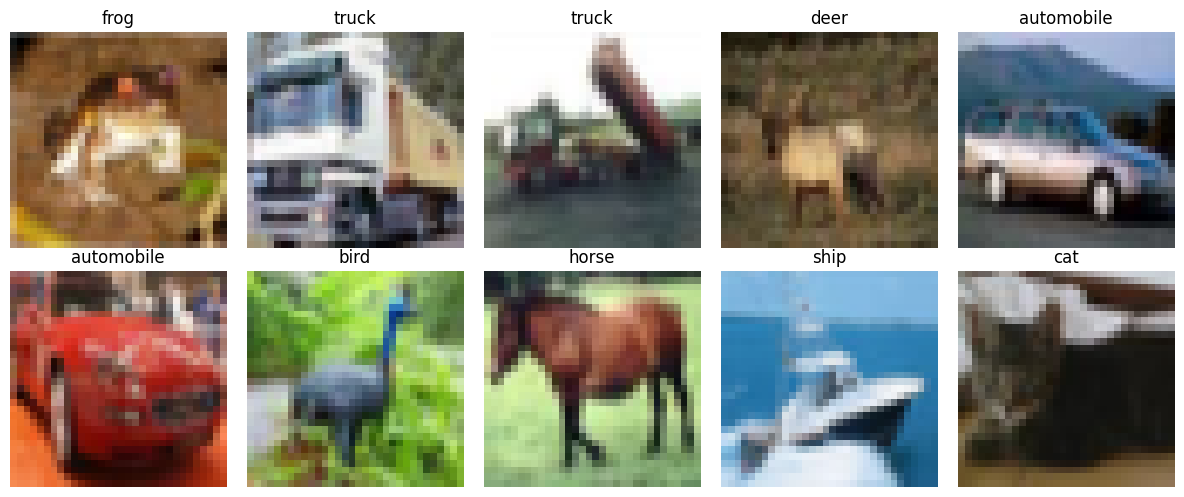

In [4]:
import matplotlib.pyplot as plt

# Show 10 sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    # Convert from [-1, 1] back to [0, 1]
    image = image * 0.5 + 0.5

    # Change from (C, H, W) to (H, W, C)
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Number of batches:", len(train_loader))

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Number of batches: 391
Batch image shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])


In [6]:
import torch

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# GAN settings
LATENT_DIM = 100
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANNELS = 3

# Training settings
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.0002

print("Device:", device)
print("Latent dimension:", LATENT_DIM)
print("Number of categories:", NUM_CLASSES)
print("Image size:", IMAGE_SIZE)
print("Channels:", CHANNELS)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Device: cuda
Latent dimension: 100
Number of categories: 10
Image size: 32
Channels: 3
Epochs: 10
Learning rate: 0.0002


In [7]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # Convert category labels into embeddings
        self.label_embedding = nn.Embedding(
            NUM_CLASSES,
            NUM_CLASSES
        )

        # Generator network
        self.model = nn.Sequential(
            nn.Linear(LATENT_DIM + NUM_CLASSES, 128 * 8 * 8),
            nn.BatchNorm1d(128 * 8 * 8),
            nn.ReLU(True),

            nn.Unflatten(1, (128, 8, 8)),

            nn.ConvTranspose2d(128, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, CHANNELS, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_embedding = self.label_embedding(labels)

        # Combine noise and category information
        input_data = torch.cat((noise, label_embedding), dim=1)

        return self.model(input_data)


generator = Generator().to(device)

print(generator)

Generator(
  (label_embedding): Embedding(10, 10)
  (model): Sequential(
    (0): Linear(in_features=110, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Unflatten(dim=1, unflattened_size=(128, 8, 8))
    (4): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): Tanh()
  )
)


In [8]:
# Generate a test batch

noise = torch.randn(8, LATENT_DIM, device=device)
labels = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7], device=device)

fake_images = generator(noise, labels)

print("Generated image shape:", fake_images.shape)

Generated image shape: torch.Size([8, 3, 32, 32])


In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # Convert category labels into embeddings
        self.label_embedding = nn.Embedding(
            NUM_CLASSES,
            IMAGE_SIZE * IMAGE_SIZE
        )

        self.model = nn.Sequential(
            nn.Conv2d(CHANNELS + 1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),

            nn.Linear(256 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, image, labels):
        label_embedding = self.label_embedding(labels)

        # Convert label embedding into a spatial map
        label_embedding = label_embedding.view(
            labels.size(0),
            1,
            IMAGE_SIZE,
            IMAGE_SIZE
        )

        # Combine image + label information
        input_data = torch.cat(
            (image, label_embedding),
            dim=1
        )

        return self.model(input_data)


discriminator = Discriminator().to(device)

print(discriminator)

Discriminator(
  (label_embedding): Embedding(10, 1024)
  (model): Sequential(
    (0): Conv2d(4, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=4096, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [10]:
# Test the discriminator

test_images = torch.randn(8, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_labels = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7], device=device)

predictions = discriminator(test_images, test_labels)

print("Prediction shape:", predictions.shape)
print("Predictions:")
print(predictions.squeeze().detach().cpu())

Prediction shape: torch.Size([8, 1])
Predictions:
tensor([0.4187, 0.3449, 0.4497, 0.3777, 0.5681, 0.4383, 0.4910, 0.3634])


In [11]:
import torch.optim as optim

# Loss function
criterion = nn.BCELoss()

# Optimizers
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

print("Loss function: Binary Cross-Entropy")
print("Optimizer: Adam")
print("Learning rate:", LEARNING_RATE)

Loss function: Binary Cross-Entropy
Optimizer: Adam
Learning rate: 0.0002


In [12]:
import os
from tqdm.auto import tqdm

os.makedirs("task2_generated_images", exist_ok=True)

G_losses = []
D_losses = []

for epoch in range(EPOCHS):

    running_G_loss = 0.0
    running_D_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for real_images, real_labels in progress_bar:

        real_images = real_images.to(device)
        real_labels = real_labels.to(device)

        batch_size = real_images.size(0)

        # ==========================================
        # 1. Train Discriminator
        # ==========================================

        optimizer_D.zero_grad()

        # Real images
        real_targets = torch.ones(
            batch_size, 1, device=device
        )

        real_output = discriminator(
            real_images,
            real_labels
        )

        real_loss = criterion(
            real_output,
            real_targets
        )

        # Generate fake images
        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = generator(
            noise,
            real_labels
        )

        fake_targets = torch.zeros(
            batch_size, 1, device=device
        )

        fake_output = discriminator(
            fake_images.detach(),
            real_labels
        )

        fake_loss = criterion(
            fake_output,
            fake_targets
        )

        # Total discriminator loss
        d_loss = real_loss + fake_loss

        d_loss.backward()
        optimizer_D.step()

        # ==========================================
        # 2. Train Generator
        # ==========================================

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        generated_images = generator(
            noise,
            real_labels
        )

        # Generator wants discriminator
        # to classify fake images as real
        generator_output = discriminator(
            generated_images,
            real_labels
        )

        g_targets = torch.ones(
            batch_size, 1, device=device
        )

        g_loss = criterion(
            generator_output,
            g_targets
        )

        g_loss.backward()
        optimizer_G.step()

        running_G_loss += g_loss.item()
        running_D_loss += d_loss.item()

        progress_bar.set_postfix({
            "D_loss": f"{d_loss.item():.4f}",
            "G_loss": f"{g_loss.item():.4f}"
        })

    avg_G_loss = running_G_loss / len(train_loader)
    avg_D_loss = running_D_loss / len(train_loader)

    G_losses.append(avg_G_loss)
    D_losses.append(avg_D_loss)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"D Loss: {avg_D_loss:.4f} | "
        f"G Loss: {avg_G_loss:.4f}"
    )

print("Training completed!")

Epoch 1/10:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch [1/10] D Loss: 1.0138 | G Loss: 1.5815


Epoch 2/10:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch [2/10] D Loss: 1.1519 | G Loss: 1.2368


Epoch 3/10:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 9/10:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch [9/10] D Loss: 0.7442 | G Loss: 1.8227


Epoch 10/10:   0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ab7a8ad9760>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    Exception ignored in: assert self._parent_pid == os.getpid(), 'can only test a child process'
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ab7a8ad9760>AssertionError
: can only test a child processTraceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Exception ignored in:     if w.is_aliv

Epoch [10/10] D Loss: 0.7602 | G Loss: 1.8064
Training completed!


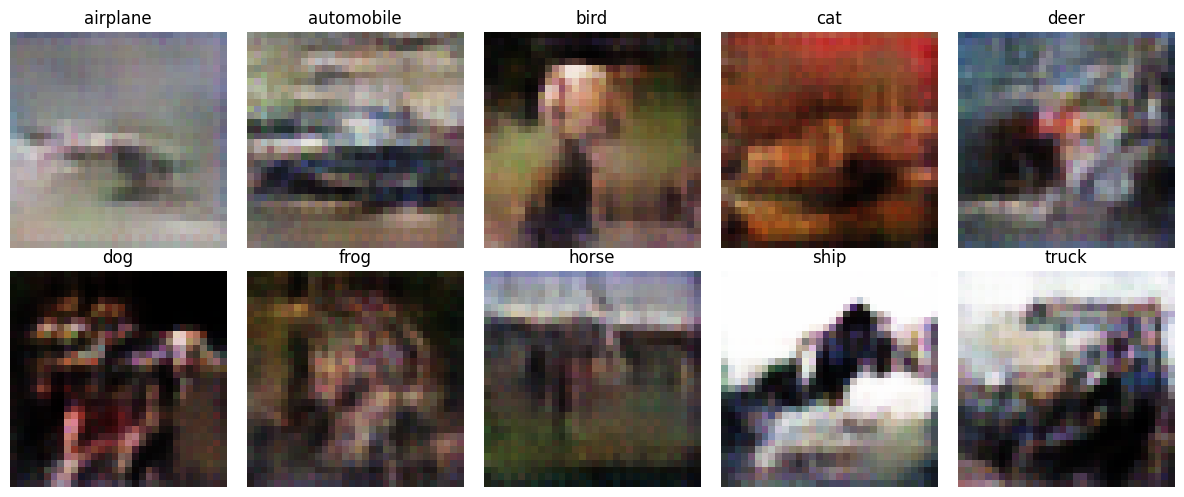

In [13]:
import matplotlib.pyplot as plt
import torch

generator.eval()

# Use the same noise for all categories
noise = torch.randn(NUM_CLASSES, LATENT_DIM, device=device)

# Labels 0 to 9
labels = torch.arange(NUM_CLASSES, device=device)

with torch.no_grad():
    generated_images = generator(noise, labels)

# Convert from [-1, 1] to [0, 1]
generated_images = (generated_images + 1) / 2
generated_images = generated_images.clamp(0, 1)

# Display results
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image = generated_images[i].permute(1, 2, 0).cpu()

    ax.imshow(image)
    ax.set_title(train_dataset.classes[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

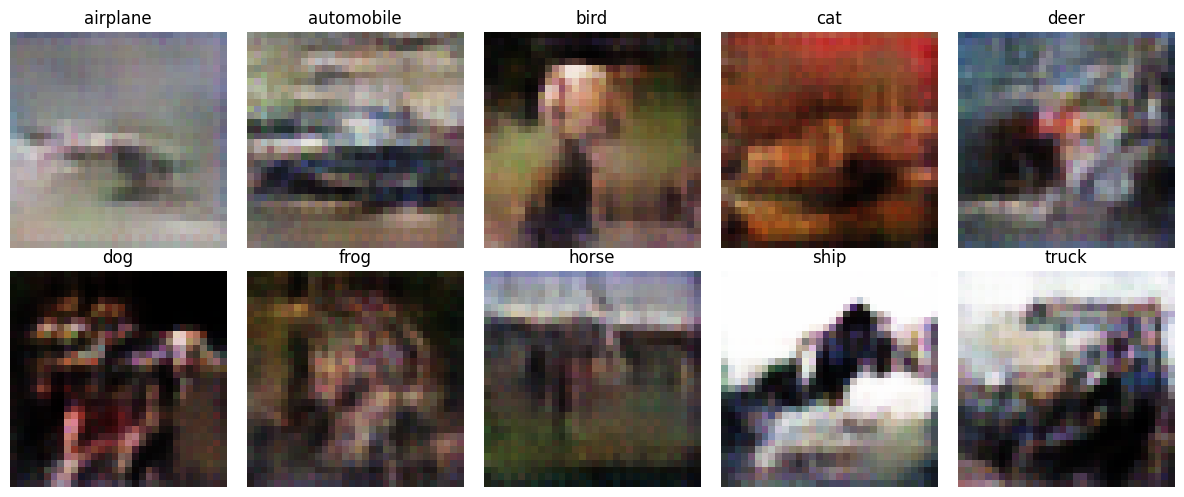

Saved: task2_generated_images/cgan_category_results.png


In [14]:
# Save the generated category results

import os
import matplotlib.pyplot as plt

os.makedirs("task2_generated_images", exist_ok=True)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image = generated_images[i].permute(1, 2, 0).cpu()
    ax.imshow(image)
    ax.set_title(train_dataset.classes[i])
    ax.axis("off")

plt.tight_layout()

output_path = "task2_generated_images/cgan_category_results.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

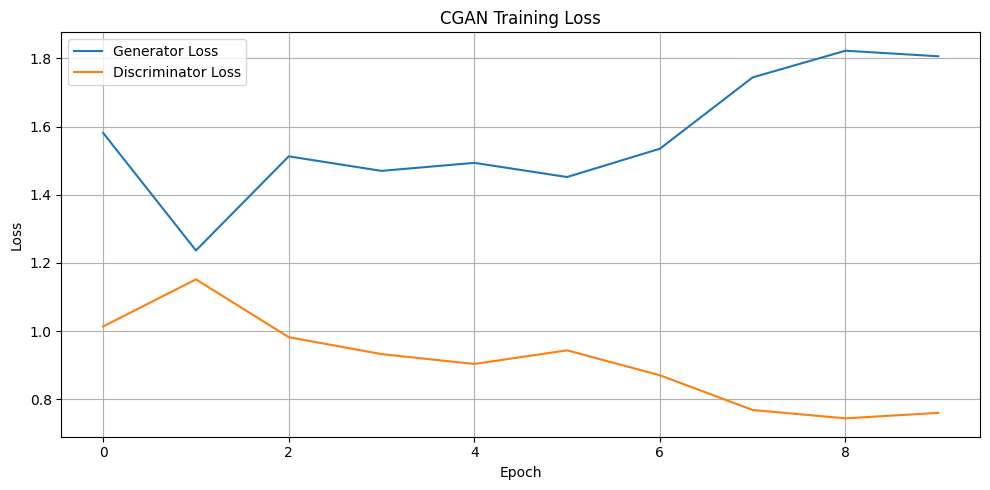

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CGAN Training Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
# Save the trained CGAN models

torch.save(generator.state_dict(), "task2_generator.pth")
torch.save(discriminator.state_dict(), "task2_discriminator.pth")

print("Generator saved: task2_generator.pth")
print("Discriminator saved: task2_discriminator.pth")

Generator saved: task2_generator.pth
Discriminator saved: task2_discriminator.pth


In [17]:
import os

print("Task 2 output files:")

for file in [
    "task2_generator.pth",
    "task2_discriminator.pth",
    "task2_generated_images/cgan_category_results.png"
]:
    if os.path.exists(file):
        size = os.path.getsize(file) / (1024 * 1024)
        print(f"✓ {file} ({size:.2f} MB)")
    else:
        print(f"✗ Missing: {file}")

Task 2 output files:
✓ task2_generator.pth (5.11 MB)
✓ task2_discriminator.pth (2.58 MB)
✓ task2_generated_images/cgan_category_results.png (0.06 MB)


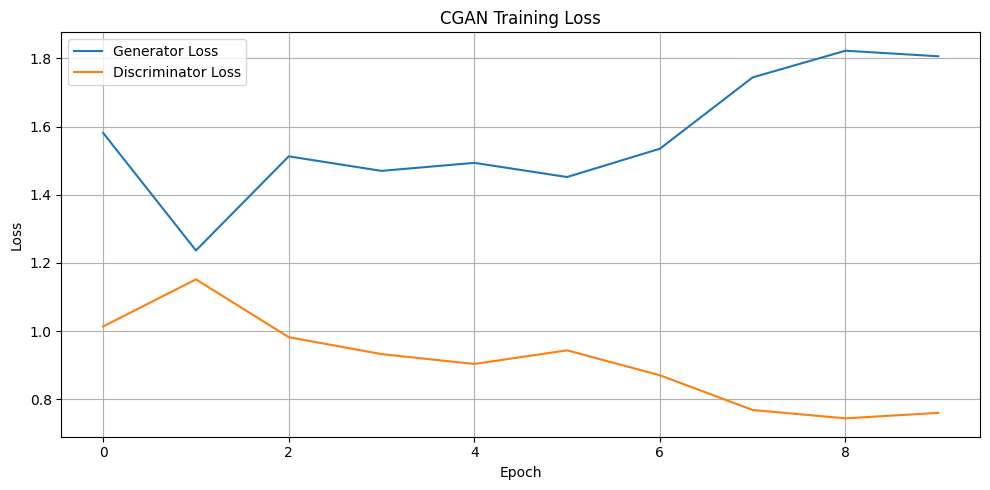

Saved: task2_generated_images/cgan_training_loss.png


In [18]:
# Save the CGAN training loss graph

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CGAN Training Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

loss_path = "task2_generated_images/cgan_training_loss.png"
plt.savefig(loss_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", loss_path)